In [13]:
!pip install jinja2
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
import matplotlib.pyplot as plt
import time
import pandas as pd

STUDENT_SEED = 421944 
IMAGE_SIZE = (128, 128)
IMAGE_SIZE_ALTERNATIVE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = 19

np.random.seed(STUDENT_SEED)
tf.random.set_seed(STUDENT_SEED)

# GPU Check since im running this locally on my NVIDIA 4060 8GB
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
model_performance_tracker = {}
model_histories = {}

## Helper Functions

These are functions used throughout the code

### Plot

In [14]:
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curves
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(histories_dict, title='Model Architecture Comparison'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for model_name, history in histories_dict.items():

        p = ax1.plot(history.history['loss'], label=f'{model_name} (Train Loss)', linestyle='-')
        color = p[0].get_color() 
        ax1.plot(history.history['val_loss'], label=f'{model_name} (Val Loss)', linestyle='--', color=color)
        
        ax2.plot(history.history['accuracy'], label=f'{model_name} (Train Acc)', linestyle='-', color=color)
        ax2.plot(history.history['val_accuracy'], label=f'{model_name} (Val Acc)', linestyle='--', color=color)

    ax1.set_title('Loss Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.set_title('Accuracy Comparison')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

## Data Preparation

- `image_dataset_from_directory` Loads the images in batches from disk rather than everything into memory at once

### References
- [TensorFlow Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory#:%7E:text=or%204%20channels.-,batch_size,-Size%20of%20the)
- [Stackoverflow](https://stackoverflow.com/questions/66036271/splitting-a-tensorflow-dataset-into-training-test-and-validation-sets-from-ker)

In [15]:
train_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

print(train_ds)

remaining_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

print(remaining_ds)

remaining_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
val_batches = int(remaining_batches * 0.33)
test_batches = remaining_batches - val_batches

val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

Found 19000 files belonging to 19 classes.
Using 13300 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [5]:
class_names = train_ds.class_names
print(class_names)

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

['carrot_cake', 'cheesecake', 'chicken_wings', 'chocolate_cake', 'donuts', 'fish_and_chips', 'french_fries', 'fried_rice', 'garlic_bread', 'hamburger', 'hot_dog', 'nachos', 'onion_rings', 'pancakes', 'pizza', 'red_velvet_cake', 'spaghetti_bolognese', 'steak', 'waffles']
Number of classes: 19


## Normalisation

Since every pixel in the image is stored as a number from 0 to 255 where like 0 is compelely dark, then 255 is full brightness, white in greyscale or full RGB. So normalising the data will map it between 0.0 and 1.0.

Doing this doesnt actually change how the image works, but it does help for weight initialisations. So later on when training starts, the weights are initialised as smaller random numbers, but if the inputs are like 0-255, the initial dot products are enourmous, which isnt good. It also works best when using the Gradient Descent optimiser ADAM

In [16]:
normalisation_layer = keras.layers.Rescaling(1./255)

## Class Imbalance

So this occurs when some categories have more images than others. For example, if Pizza has 2000 images but sushi has 200, the model will acheive 90% accuracy by just predicing pizza, making it useless for other classes.

### Checking for class distribution

First we can check for the distribution for each image type, since the folders are named after the food they contain, it makes it easier to plot them on a bar chart, the results show that for each food type, there is 1000 images, so there is equal class distribution.

```
=> carrot_cake: 1000
=> cheesecake: 1000
=> chicken_wings: 1000
=> chocolate_cake: 1000
=> donuts: 1000
=> fish_and_chips: 1000
=> french_fries: 1000
=> fried_rice: 1000
=> garlic_bread: 1000
=> hamburger: 1000
=> hot_dog: 1000
=> nachos: 1000
=> onion_rings: 1000
=> pancakes: 1000
=> pizza: 1000
=> red_velvet_cake: 1000
=> spaghetti_bolognese: 1000
=> steak: 1000
=> waffles: 1000
```

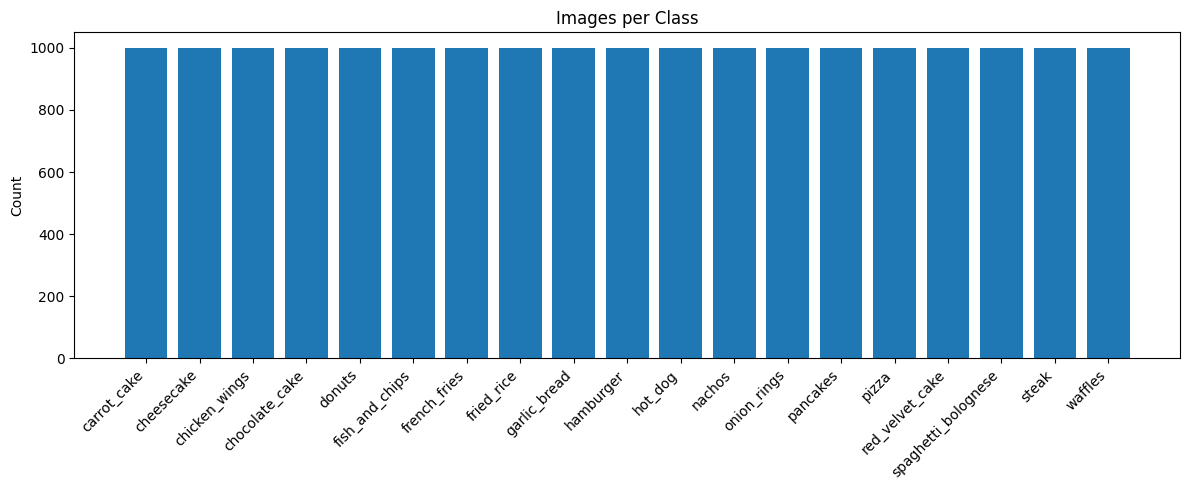

=> carrot_cake: 1000
=> cheesecake: 1000
=> chicken_wings: 1000
=> chocolate_cake: 1000
=> donuts: 1000
=> fish_and_chips: 1000
=> french_fries: 1000
=> fried_rice: 1000
=> garlic_bread: 1000
=> hamburger: 1000
=> hot_dog: 1000
=> nachos: 1000
=> onion_rings: 1000
=> pancakes: 1000
=> pizza: 1000
=> red_velvet_cake: 1000
=> spaghetti_bolognese: 1000
=> steak: 1000
=> waffles: 1000


In [17]:
import os
import matplotlib.pyplot as plt

data_dir = './food/'
class_counts = {}

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count

# Plot it
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title('Images per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

for name, count in class_counts.items():
    print(f"=> {name}: {count}")

### Imbalanced Classes

Although the images provided in the food dataset is perfectly balanced at 1000 images, this isnt always the case. Many real world datasets would have variation in the number of images, which will create an imbalance.

In this way, the model learns to favour majority classes, where teh accuracy looks high but minority class performance is terrible. Introducing class weights will allow each class to be treated fairly.

In [18]:
import numpy as np

total_images = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = {}
for i, class_name in enumerate(sorted(class_counts.keys())):
    count = class_counts[class_name]
    # Classes with fewer images get higher weight
    weight = total_images / (num_classes * count)
    class_weights[i] = weight

print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0}


## Exploratory Data Analysis

Number of classes: 19
Number of images: 19000
Image size: 128×128
Colour mode: RGB (3 channels)
Train: 13312 images
Val:   1888 images
Test:  3840 images


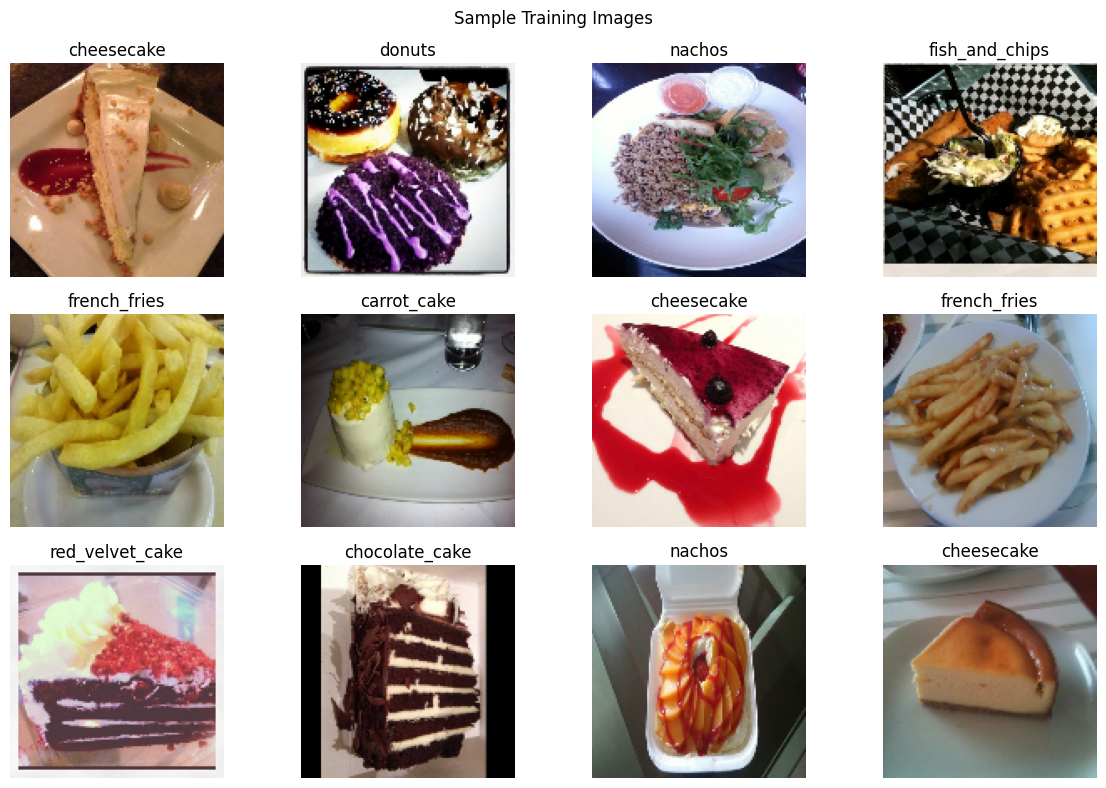

In [19]:
print(f"Number of classes: {len(class_counts)}")
print(f"Number of images: {total_images}")

for images, labels in train_ds.take(1):
    h, w, c = images[0].shape
    print(f"Image size: {h}×{w}")
    print(f"Colour mode: {'RGB' if c == 3 else 'Greyscale'} ({c} channel{'s' if c > 1 else ''})")

train_count = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
val_count   = tf.data.experimental.cardinality(val_ds).numpy()   * BATCH_SIZE
test_count  = tf.data.experimental.cardinality(test_ds).numpy()  * BATCH_SIZE

print(f"Train: {train_count} images")
print(f"Val:   {val_count} images")
print(f"Test:  {test_count} images")


plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1): 
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## CNN From Scratch

### Baseline Model

In [21]:
def build_baseline_cnn(input_shape, num_classes, target_size=(244, 244)):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Resizing(target_size[0], target_size[1]),
        layers.Rescaling(1./255),

        # BLOCK 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # BLOCK 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CLASSIFIER
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

baseline_model = build_baseline_cnn(
    input_shape=(128, 128, 3), 
    num_classes=NUM_CLASSES, 
    target_size=IMAGE_SIZE
)
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,410,579 (32.08 MB)

 Trainable params: 8,410,579 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model

- `loss='sparse_categorical_crossentropy',` labels are ints like 0,1,2,3 etc

In [22]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the model

So based on the data results produced and graphed below, we will notice that over the course of the 20 epochs that the training loss decreases while the validation loss increases. As well the training accurracy increases and the val stops around 2.2 accuracy.

This is a clear sign of overfitting, as the training loss decreases while validation increases in loss. The model is failing to learn general patterns, but instead memorising the training images!

To combat this, will add a dropout to the neural network, and augment the data such as rotating images etc

In [38]:
start_time = time.time()

EPOCHS=20

baseline_model_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Baseline CNN"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Image Size": IMAGE_SIZE,
    "Final Train Acc": round(baseline_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(baseline_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(baseline_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(baseline_model_history.history['val_loss'][-1], 4)  
}

Epoch 1/20


188/416 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9855 - loss: 0.0501

KeyboardInterrupt: 

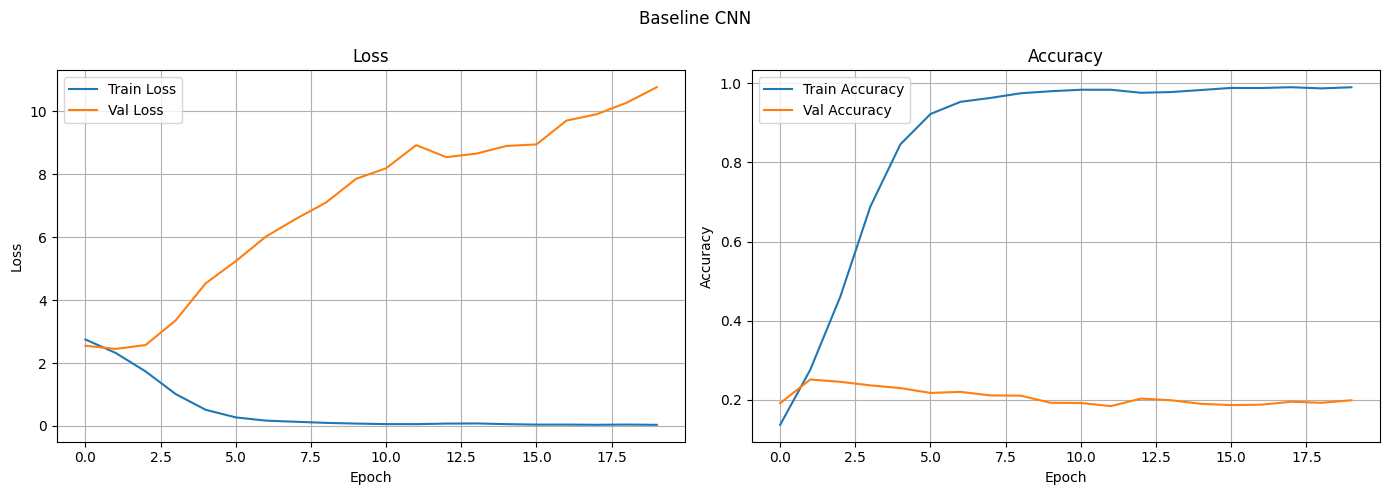

In [12]:
plot_history(baseline_model_history, title='Baseline CNN')

#### Improving the Model

So as mentioned above, the model is struggling to generalise on unseen data from our validation set, instead is memorising training patterns and images. To help combat this, I will be increasing the block count from 2 - 3, adding dropout at 0.5 and increasing the convolution layers to 2 before downsampling, to hopefully allow to to extract more complex patterns.

In [25]:
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    
    deeper_model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Resizing(current_size[0], current_size[1]),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    deeper_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()
    
    EPOCHS = 20

    deeper_model_history = deeper_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights
    )

    end_time = time.time()
    total_time = end_time - start_time

    tracker_key = f"Model V2 ({current_size[0]}x{current_size[1]})"

    history_key = f"V2_{current_size[0]}x{current_size[1]}"
    model_histories[history_key] = deeper_model_history
    
    model_performance_tracker[tracker_key] = {
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / EPOCHS, 2),
        "Epochs": EPOCHS,
        "Image Size": current_size,
        "Final Train Acc": round(deeper_model_history.history['accuracy'][-1], 4),
        "Final Val Acc": round(deeper_model_history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(deeper_model_history.history['loss'][-1], 4), 
        "Final Val Loss": round(deeper_model_history.history['val_loss'][-1], 4)  
    }

Epoch 1/20


I0000 00:00:1778002038.765837  181678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68375__.45


415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0525 - loss: 2.9512

I0000 00:00:1778002060.079105  181679 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68375__.45


416/416 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.0512 - loss: 2.9461 - val_accuracy: 0.0471 - val_loss: 2.9448
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.0497 - loss: 2.9448 - val_accuracy: 0.0556 - val_loss: 2.9449
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.0539 - loss: 2.9447 - val_accuracy: 0.0551 - val_loss: 2.9451
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0529 - loss: 2.9446 - val_accuracy: 0.0572 - val_loss: 2.9449
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0517 - loss: 2.9446 - val_accuracy: 0.0561 - val_loss: 2.9450
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0527 - loss: 2.9446 - val_accuracy: 0.0535 - val_loss: 2.9453
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0529 - loss: 2.9446 - val_accuracy: 0.0561 - val_loss: 2.9453
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0522 - loss: 2.9446 - val_accurac

I0000 00:00:1778002346.330585  181678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_110178__.45


415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0651 - loss: 2.9178

I0000 00:00:1778002358.624130  181678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_110178__.45


416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.0853 - loss: 2.8681 - val_accuracy: 0.1271 - val_loss: 2.7697
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1262 - loss: 2.7463 - val_accuracy: 0.1499 - val_loss: 2.7136
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1584 - loss: 2.6571 - val_accuracy: 0.1594 - val_loss: 2.6574
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1898 - loss: 2.5792 - val_accuracy: 0.1875 - val_loss: 2.5628
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2255 - loss: 2.4745 - val_accuracy: 0.2240 - val_loss: 2.5033
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2632 - loss: 2.3664 - val_accuracy: 0.2415 - val_loss: 2.4172
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2957 - loss: 2.2576 - val_accuracy: 0.2632 - val_loss: 2.4020
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3345 - loss: 2.1324 - val_accuracy: 0.27

#### Combatting Underfitting

This is a case now where the model is underfitting on the data, rather than overfitting. Based on the chart data the model is struggling with around 5% accuracy for validation and the model cant find any more patterns to improve its accuracy.

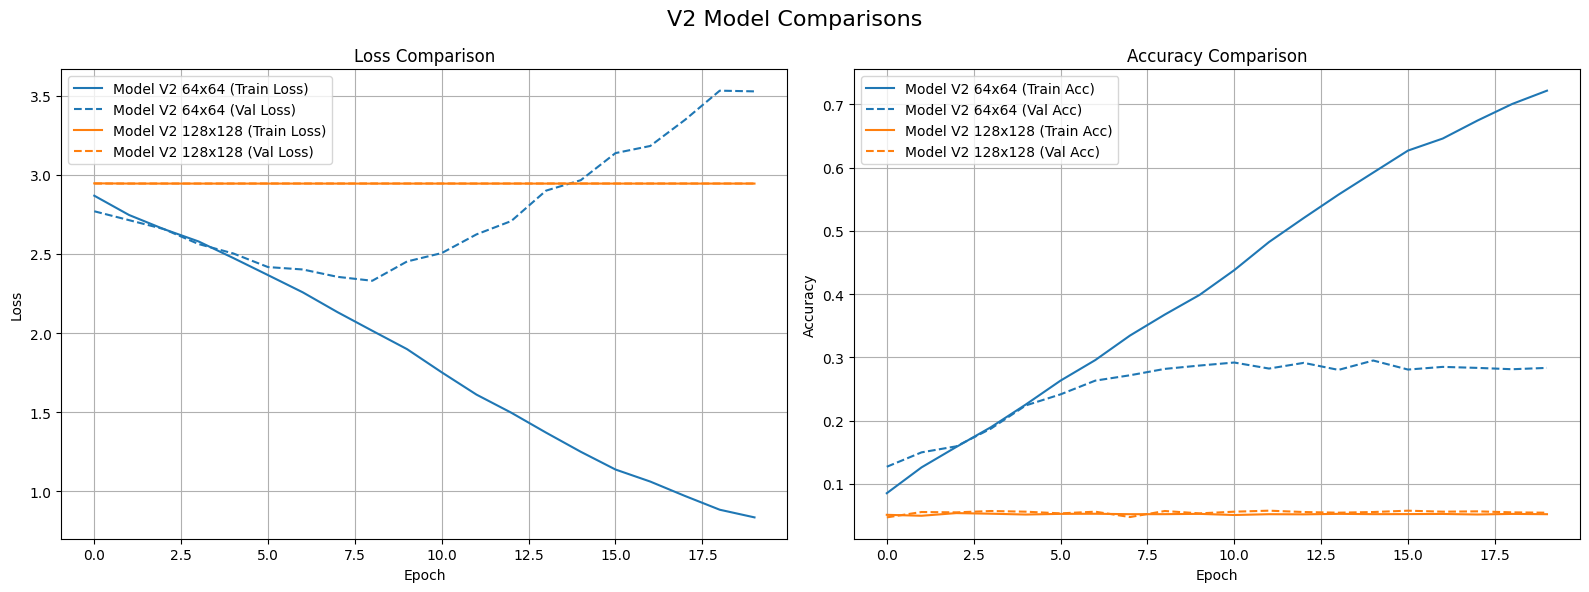

In [32]:

v2_models = {
    'Model V2 64x64': model_histories["V2_64x64"],
    "Model V2 128x128": model_histories["V2_128x128"]
}

plot_model_comparison(v2_models, title="V2 Model Comparisons")

#### Batch stuff (Overfitting)

The model is improving far better than before, with the training loss steadily decreasing smoothly with every epoch, showing it is finding and learning different patterns from our data. As well the train accuracy is increasing steadily with it. The validation set is performing better than before as the accuracy is increasing along with the training acurracy albeit stagnant.

In [29]:
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Resizing(current_size[0], current_size[1]),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(), 
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()
    EPOCHS=40

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights
    )

    end_time = time.time()
    total_time = end_time - start_time

    tracker_key = f"Model V3 ({current_size[0]}x{current_size[1]})"
    history_key = f"V3_{current_size[0]}x{current_size[1]}"
    
    model_histories[history_key] = history
    
    model_performance_tracker[tracker_key] = {
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / EPOCHS, 2),
        "Epochs": EPOCHS,
        "Image Size": current_size,
        "Final Train Acc": round(history.history['accuracy'][-1], 4),
        "Final Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(history.history['loss'][-1], 4), 
        "Final Val Loss": round(history.history['val_loss'][-1], 4)  
    }

Epoch 1/40


I0000 00:00:1778002725.250151  181681 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151763__.45
I0000 00:00:1778002725.467690  181681 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


413/416 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0799 - loss: 2.9787

I0000 00:00:1778002736.817426  181681 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151763__.45


416/416 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.0916 - loss: 2.9203 - val_accuracy: 0.1081 - val_loss: 2.8814
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1381 - loss: 2.7681 - val_accuracy: 0.1870 - val_loss: 2.7012
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1640 - loss: 2.6856 - val_accuracy: 0.2097 - val_loss: 2.6122
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1871 - loss: 2.6206 - val_accuracy: 0.2214 - val_loss: 2.5626
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.2044 - loss: 2.5672 - val_accuracy: 0.2447 - val_loss: 2.5043
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.2195 - loss: 2.5123 - val_accuracy: 0.2405 - val_loss: 2.4732
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2292 - loss: 2.4687 - val_accuracy: 0.2447 - val_loss: 2.4368
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2446 - loss: 2.4380 - val_accuracy: 0.26

I0000 00:00:1778003033.189085  181682 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231685__.45


409/416 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0696 - loss: 3.0030

I0000 00:00:1778003038.432350  181679 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231685__.45


416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.0828 - loss: 2.9384 - val_accuracy: 0.1065 - val_loss: 2.8840
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1201 - loss: 2.8077 - val_accuracy: 0.1679 - val_loss: 2.7326
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1575 - loss: 2.7266 - val_accuracy: 0.1923 - val_loss: 2.6645
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1707 - loss: 2.6617 - val_accuracy: 0.2002 - val_loss: 2.6014
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1924 - loss: 2.6019 - val_accuracy: 0.2188 - val_loss: 2.5569
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1981 - loss: 2.5651 - val_accuracy: 0.2394 - val_loss: 2.4997
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2180 - loss: 2.5063 - val_accuracy: 0.2368 - val_loss: 2.4620
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2311 - loss: 2.4654 - val_accuracy: 0.2606 - va

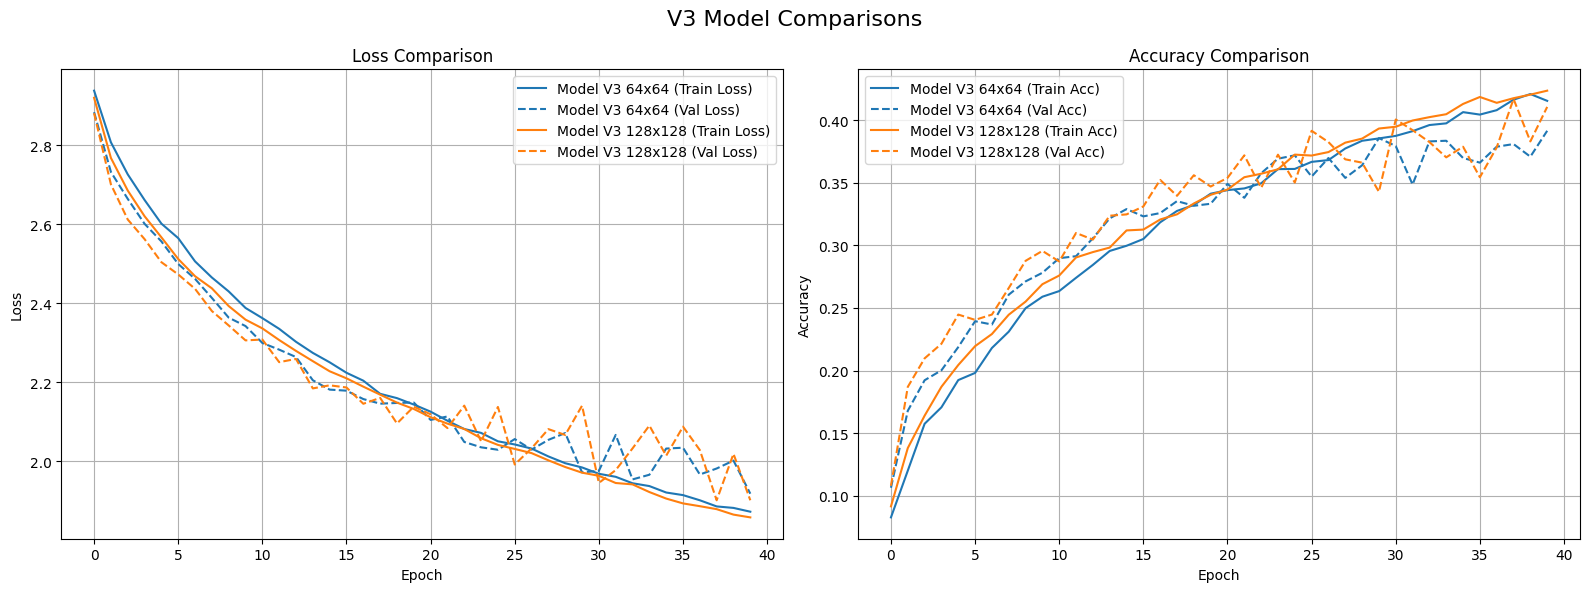

In [ ]:
v3_models = {
    'Model V3 64x64': model_histories["V3_64x64"],
    "Model V3 128x128": model_histories["V3_128x128"]
}

plot_model_comparison(v3_models, title="V3 Model Comparisons")

## Good stable

Both training accuracy and validatio accuracy increasing together.

Added 

```
layers.RandomFlip('horizontal'),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
```

and made epochs 40

"Adding rotation and zoom augmentation improved the stability of the training loss but introduced significant volatility in the validation metrics. The final validation accuracy of 38% suggests that while the model is learning general features, it remains sensitive to extreme image transformations."

In [33]:
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    
    model = keras.Sequential([
        # 1. Ingestion & Resizing
        layers.Input(shape=(128, 128, 3)),
        layers.Resizing(current_size[0], current_size[1]),

        # 2. Augmentation (Core V4 functionality)
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # 3. Preprocessing & Feature Extraction
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 4. Classifier
        layers.GlobalAveragePooling2D(), 
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 5. Training Execution
    start_time = time.time()
    EPOCHS = 60 # Model V4 uses 60 epochs

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights
    )

    end_time = time.time()
    total_time = end_time - start_time

    # 6. Performance & History Tracking
    tracker_key = f"Model V4 ({current_size[0]}x{current_size[1]})"
    history_key = f"V4_{current_size[0]}x{current_size[1]}"
    
    model_histories[history_key] = history
    
    model_performance_tracker[tracker_key] = {
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / EPOCHS, 2),
        "Epochs": EPOCHS,
        "Image Size": current_size,
        "Final Train Acc": round(history.history['accuracy'][-1], 4),
        "Final Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(history.history['loss'][-1], 4), 
        "Final Val Loss": round(history.history['val_loss'][-1], 4)  
    }

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.0900 - loss: 2.9040 - val_accuracy: 0.1149 - val_loss: 2.8696
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.1302 - loss: 2.7961 - val_accuracy: 0.1626 - val_loss: 2.7457
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.1562 - loss: 2.7313 - val_accuracy: 0.1647 - val_loss: 2.7012
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.1665 - loss: 2.6698 - val_accuracy: 0.1716 - val_loss: 2.6639
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.1887 - loss: 2.6098 - val_accuracy: 0.1573 - val_loss: 2.6734
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.2039 - loss: 2.5676 - val_accuracy: 0.1552 - val_loss: 2.7129
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.2194 - loss: 2.5263 - val_accuracy: 0.2023 - val_loss: 2.5707
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.2287 - loss: 2.4791 - 

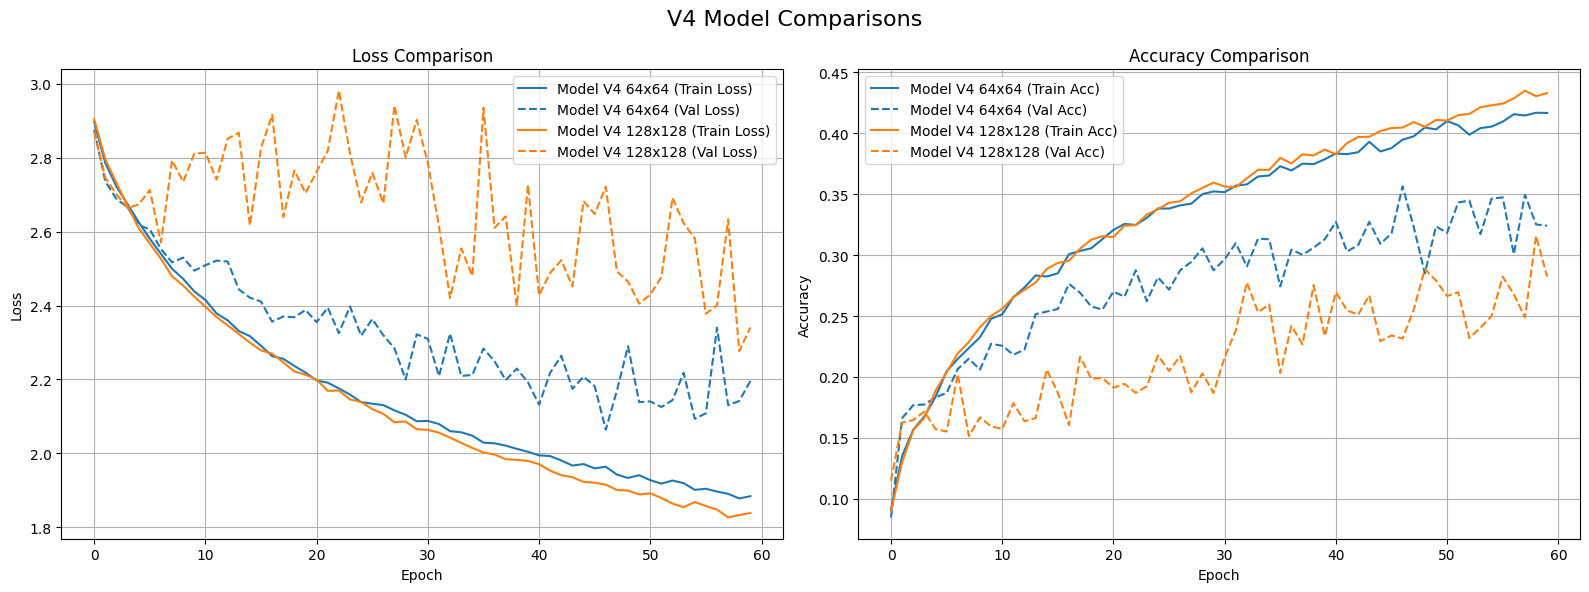

In [34]:
v4_models = {
    'Model V4 64x64': model_histories["V4_64x64"],
    "Model V4 128x128": model_histories["V4_128x128"]
}

plot_model_comparison(v4_models, title="V4 Model Comparisons")

In [35]:
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    
    model = keras.Sequential([
        # 1. Ingestion & Resizing
        layers.Input(shape=(128, 128, 3)),
        layers.Resizing(current_size[0], current_size[1]),

        # 2. Augmentation
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # 3. Preprocessing
        layers.Rescaling(1./255),

        # 4. Deep Feature Extraction (V5 Blocks)
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # 5. Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001), # Back to 0.001 for V5
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 6. Callback Definition (Local to loop to reset state)
    callback = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )

    # 7. Training
    start_time = time.time()
    MAX_EPOCHS = 40

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        class_weight=class_weights,
        callbacks=[callback]
    )

    end_time = time.time()
    total_time = end_time - start_time
    actual_epochs = len(history.history['loss']) # Accounts for Early Stopping

    # 8. Tracking
    tracker_key = f"Model V5 ({current_size[0]}x{current_size[1]})"
    history_key = f"V5_{current_size[0]}x{current_size[1]}"
    
    model_histories[history_key] = history
    
    model_performance_tracker[tracker_key] = {
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / actual_epochs, 2),
        "Epochs": actual_epochs,
        "Image Size": current_size,
        "Final Train Acc": round(history.history['accuracy'][-1], 4),
        "Final Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(history.history['loss'][-1], 4), 
        "Final Val Loss": round(history.history['val_loss'][-1], 4)  
    }

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.1708 - loss: 2.6950 - val_accuracy: 0.1065 - val_loss: 3.2553
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.2682 - loss: 2.3548 - val_accuracy: 0.2606 - val_loss: 2.4738
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.3371 - loss: 2.1352 - val_accuracy: 0.2251 - val_loss: 2.4829
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.3960 - loss: 1.9687 - val_accuracy: 0.1997 - val_loss: 2.8049
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4407 - loss: 1.8048 - val_accuracy: 0.3946 - val_loss: 2.0418
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4842 - loss: 1.6812 - val_accuracy: 0.2474 - val_loss: 2.7638
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.5168 - loss: 1.5763 - val_accuracy: 0.3353 - val_loss: 2.4981
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.5439 - loss: 1.4843 - 

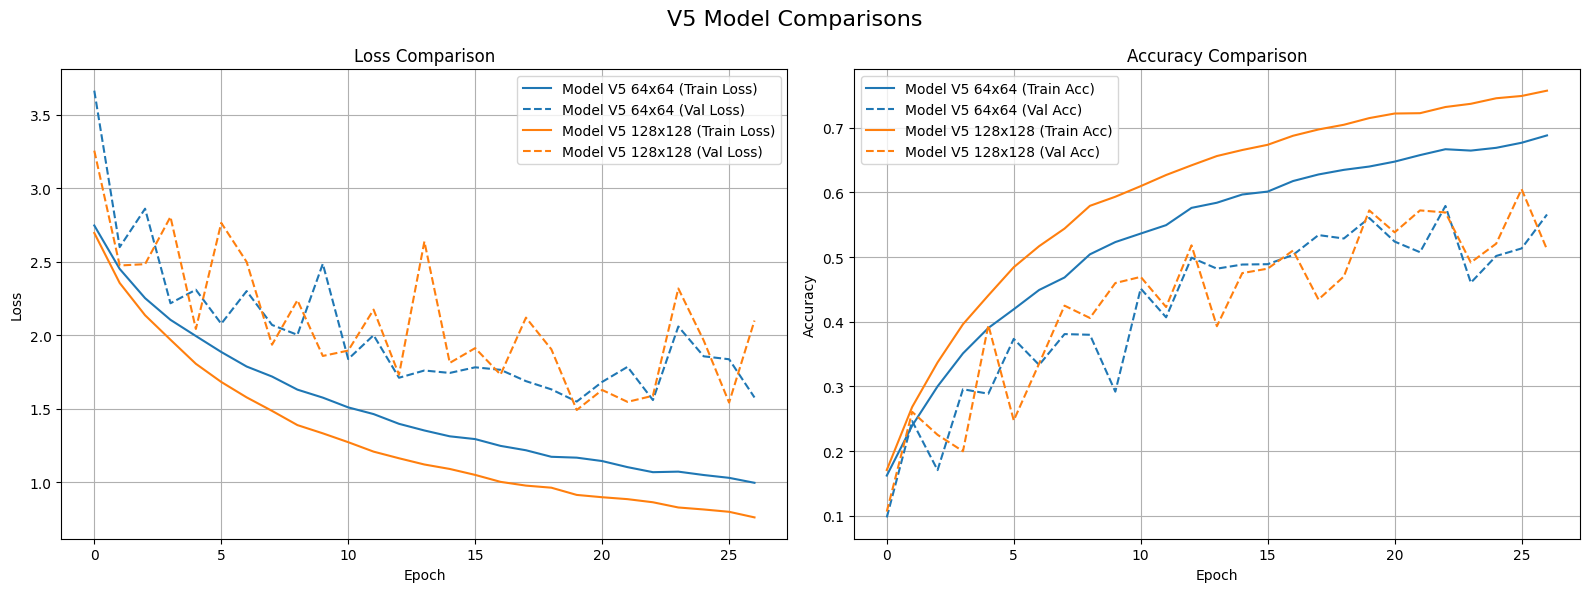

In [37]:
v5_models = {
    'Model V5 64x64': model_histories["V5_64x64"],
    "Model V5 128x128": model_histories["V5_128x128"]
}

plot_model_comparison(v5_models, title="V5 Model Comparisons")

#### Model v6

In [ ]:
def build_food_cnn_v6(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v6_model = build_food_cnn_v6(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

build_food_cnn_v6_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=50

build_food_cnn_v6_model_history = build_food_cnn_v6_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V6"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v6_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v6_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v6_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v6_model_history.history['val_loss'][-1], 4)  
}


Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.1595 - loss: 3.0098 - val_accuracy: 0.1684 - val_loss: 2.6941
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.2452 - loss: 2.4455 - val_accuracy: 0.2717 - val_loss: 2.3920
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.3010 - loss: 2.2640 - val_accuracy: 0.2722 - val_loss: 2.5126
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.3500 - loss: 2.1140 - val_accuracy: 0.2802 - val_loss: 2.3220
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.3987 - loss: 1.9576 - val_accuracy: 0.3088 - val_loss: 2.4864
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.4416 - loss: 1.8382 - val_accuracy: 0.3882 - val_loss: 2.0509
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.4845 - loss: 1.7188 - val_accuracy: 0.3602 - val_loss: 2.1239
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.5143 - loss: 1.5942 - 

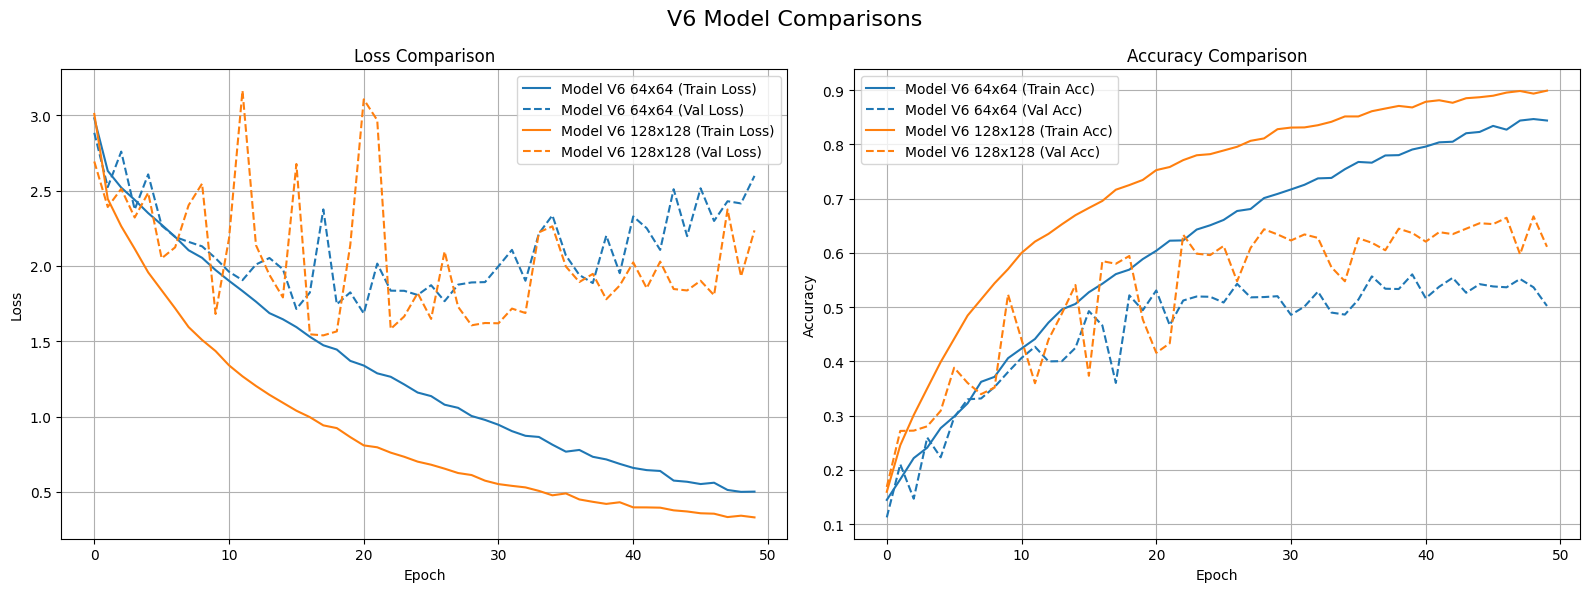

In [40]:
v6_models = {
    'Model V6 64x64': model_histories["V6_64x64"],
    "Model V6 128x128": model_histories["V6_128x128"]
}

plot_model_comparison(v6_models, title="V6 Model Comparisons")

#### Model v7

In [ ]:
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    print(f"\n--- Training Optimized V7: {current_size[0]}x{current_size[1]} ---")
    
    model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)), 
        layers.Resizing(current_size[0], current_size[1]),

        # 1. Augmentation & Preprocessing
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.Rescaling(1./255),

        # 2. Feature Extraction (Preserving spatial info at the end)
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(momentum=0.9), # Stabilized BN
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(momentum=0.9),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(momentum=0.9),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(momentum=0.9),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(momentum=0.9),

        # 3. Hybrid Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.6), 
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    # 4. Optimizer & Callbacks
    # Starting slightly higher so ReduceLROnPlateau has room to work
    optimizer = keras.optimizers.Adam(learning_rate=0.0005) 

    model.compile(
        optimizer=optimizer,
        # Label smoothing prevents the 'Confidentially Wrong' spikes in validation loss
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Intelligent cooling: drops LR when the validation loss stops improving
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=4, 
        min_lr=1e-6,
        verbose=1
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',    
        patience=10,            
        restore_best_weights=True, 
        mode='min',     
        verbose=1            
    )

    # 5. Training Execution
    start_time = time.time()
    MAX_EPOCHS = 50 # Increased because EarlyStopping will catch it if it finishes early

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr]
    )

    end_time = time.time()
    total_time = end_time - start_time
    actual_epochs = len(history.history['loss'])

    # 6. Tracking
    tracker_key = f"Model V7 ({current_size[0]}x{current_size[1]})"
    history_key = f"V7_{current_size[0]}x{current_size[1]}"
    
    model_histories[history_key] = history
    
    model_performance_tracker[tracker_key] = {
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / actual_epochs, 2),
        "Epochs Trained": actual_epochs,
        "Image Size": current_size,
        "Final Train Acc": round(history.history['accuracy'][-1], 4),
        "Final Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(history.history['loss'][-1], 4), 
        "Final Val Loss": round(history.history['val_loss'][-1], 4)  
    }


--- Training Optimized V7: 128x128 ---
Epoch 1/50


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 19)

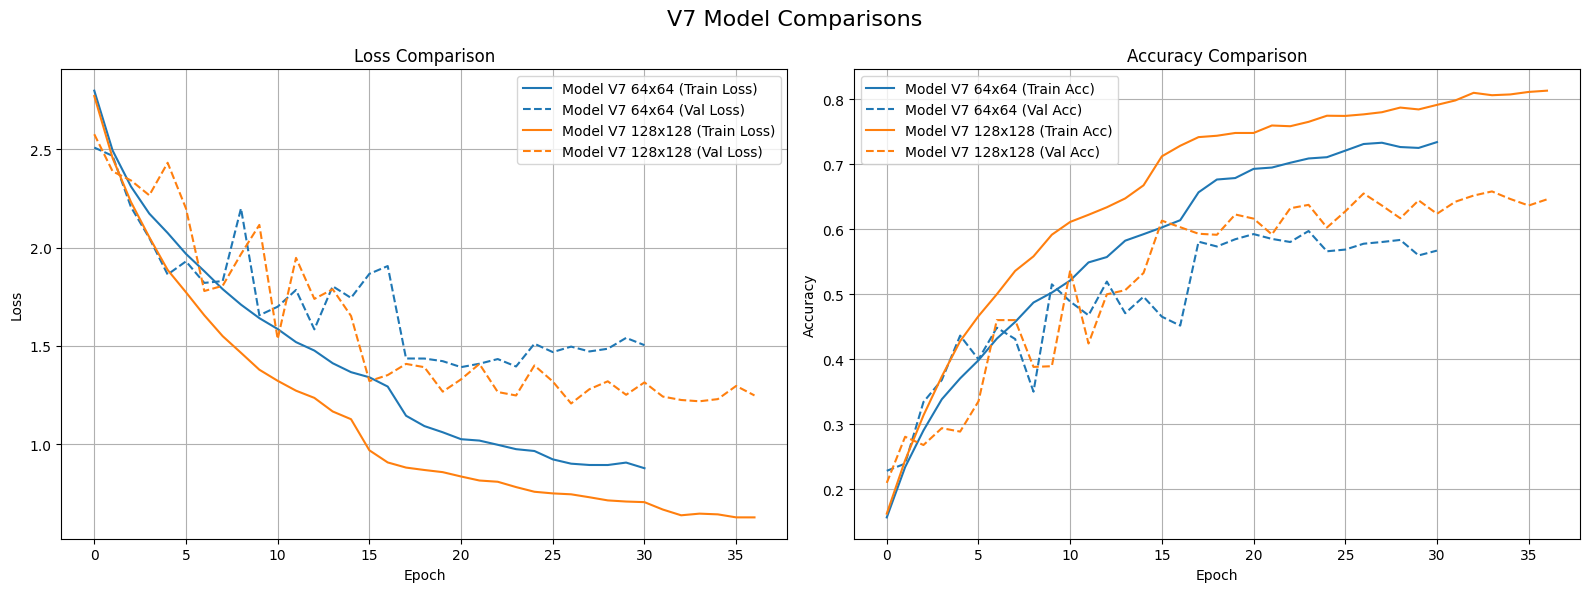

In [49]:
v7_models = {
    'Model V7 64x64': model_histories["V7_64x64"],
    "Model V7 128x128": model_histories["V7_128x128"]
}

plot_model_comparison(v7_models, title="V7 Model Comparisons")

#### Grayscale (Model V6)

In [ ]:
train_ds_gray = keras.utils.image_dataset_from_directory(
    "./food",
    color_mode='grayscale',
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

print(train_ds_gray)

remaining_ds_gray = keras.utils.image_dataset_from_directory(
    "./food",
    color_mode='grayscale',
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

print(remaining_ds_gray)

remaining_batches_gray = tf.data.experimental.cardinality(remaining_ds_gray).numpy()
val_batches_gray = int(remaining_batches_gray * 0.33)
test_batches_gray = remaining_batches_gray - val_batches_gray

val_ds_gray = remaining_ds_gray.take(val_batches_gray)
test_ds_gray = remaining_ds_gray.skip(val_batches_gray)

Found 19000 files belonging to 19 classes.
Using 13300 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
def build_food_cnn_v6_grayscale(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v6_grayscale_model = build_food_cnn_v6_grayscale(input_shape=(128, 128, 1), num_classes=NUM_CLASSES)

build_food_cnn_v6_grayscale_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=50

build_food_cnn_v6_grayscale_model_history = build_food_cnn_v6_grayscale_model.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V6 Grayscale"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v6_grayscale_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v6_grayscale_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v6_grayscale_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v6_grayscale_model_history.history['val_loss'][-1], 4)  
}


plot_history(build_food_cnn_v6_grayscale_model_history, title='Model 6 Grayscale')


Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.1441 - loss: 2.9381 - val_accuracy: 0.1006 - val_loss: 3.3990
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2172 - loss: 2.5184 - val_accuracy: 0.1483 - val_loss: 2.8306
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2662 - loss: 2.3638 - val_accuracy: 0.2452 - val_loss: 2.4288
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.3072 - loss: 2.2154 - val_accuracy: 0.1155 - val_loss: 3.4481
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.3598 - loss: 2.0942 - val_accuracy: 0.1075 - val_loss: 4.4573
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.3905 - loss: 1.9822 - val_accuracy: 0.3792 - val_loss: 2.1098
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.4336 - loss: 1.8488 - val_accuracy: 0.3676 - val_loss: 2.0866
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4648 - loss: 1.7663 - 

KeyboardInterrupt: 

## Compare

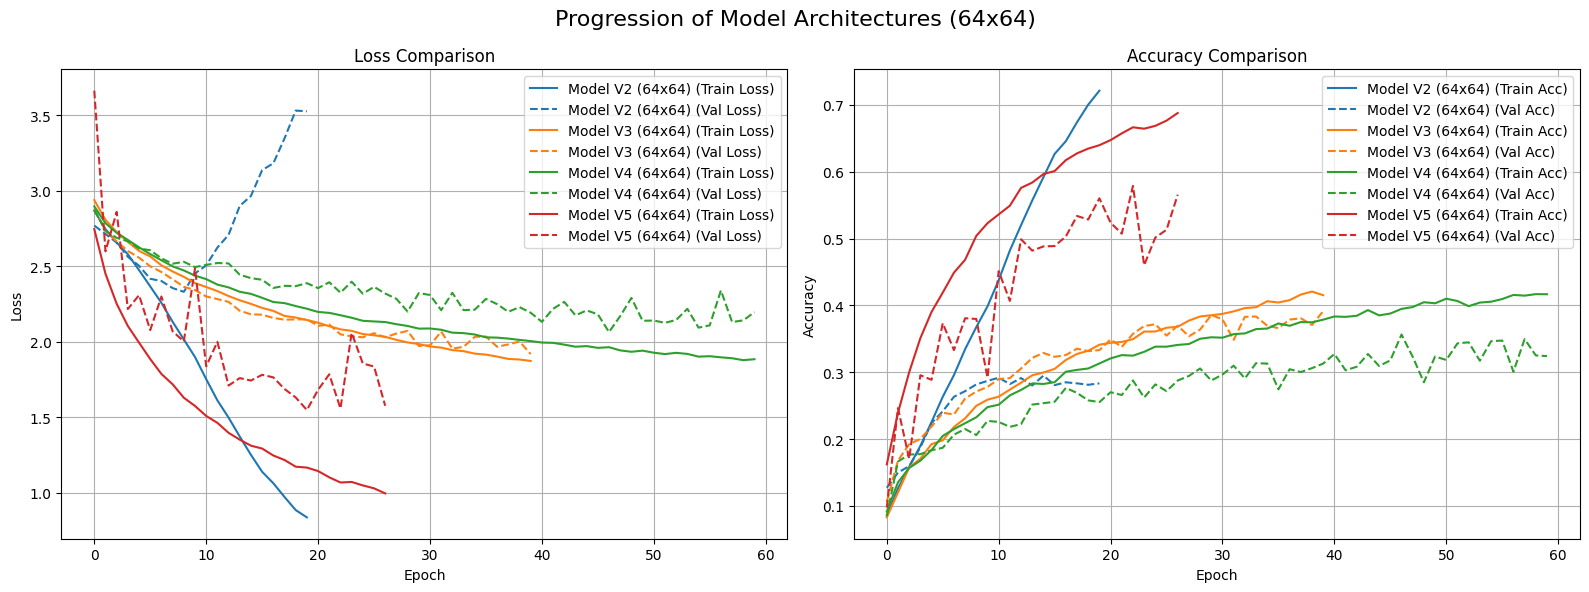

NameError: name 'build_food_cnn_v6_model_history' is not defined

In [ ]:
# Create the dictionary by fetching the 64x64 versions from your storage
my_models_64 = {
    "Model V2 (64x64)": model_histories.get("V2_64x64"),
    "Model V3 (64x64)": model_histories.get("V3_64x64"),
    "Model V4 (64x64)": model_histories.get("V4_64x64"),
    "Model V5 (64x64)": model_histories.get("V5_64x64"),
    "Model V6 (64x64)": model_histories.get("V6_64x64"),
    "Model V7 (64x64)": model_histories.get("V7_64x64"),
    "Model V8 (64x64)": model_histories.get("V8_64x64"),
}

# Remove any None values in case a model didn't finish training
my_models_64 = {k: v for k, v in my_models_64.items() if v is not None}

# Run the plot
plot_model_comparison(my_models_64, title='Progression of Model Architectures (64x64)')

my_models_grayscale = {
    'Model V6 RGB': model_histories.get("V6_64x64"),
    'Model V6 Grayscale': build_food_cnn_v6_grayscale_model_history,
}

plot_model_comparison(my_models_grayscale, title='Chosen Model v6 RGB vs Grayscale')

results_df = pd.DataFrame.from_dict(model_performance_tracker, orient='index')

# 2. Safety check: Only proceed if the DataFrame actually has data
if not results_df.empty:
    # 3. Calculate the improvement percentage relative to the first row (Baseline)
    # This creates a new column showing how much better each model is than the start
    baseline_acc = results_df.iloc[0]['Final Val Acc']
    results_df['Improvement (%)'] = (results_df['Final Val Acc'] - baseline_acc) * 100
    
    # 4. Round everything to 4 decimal places for a professional look
    results_df = results_df.round(4)
    
    # 5. Display the final table (Plain and clean, no .style needed)
    print("--- Final Model Performance Comparison ---")
    display(results_df)
else:
    print("Error: No data found in 'model_performance_tracker'.")
    print("Please ensure you've run the cells that save your model stats!")

# Transfer Learning

In [ ]:
IMAGE_SIZE_TL = (128, 128)

train_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

remaining_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

remaining_batches = tf.data.experimental.cardinality(remaining_ds_tl).numpy()
val_batches = int(remaining_batches * 0.33)

val_ds_tl = remaining_ds_tl.take(val_batches)
test_ds_tl = remaining_ds_tl.skip(val_batches)


In [ ]:
import keras
from keras import layers
from keras.applications import MobileNetV2  # or VGG16, ResNet50

IMAGE_SIZE = (128, 128)  # match what the base model was trained on

# Step 1: Load the pre-trained base model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,     # don't include the original ImageNet classifier
    weights='imagenet'     # use weights pre-trained on ImageNet
)

# Step 2: Freeze the base model — don't update its weights
base_model.trainable = False

print(f"Base model parameters: {base_model.count_params():,}")
print(f"Trainable: {sum([tf.size(v).numpy() for v in base_model.trainable_variables])}")

In [ ]:
# Step 3: Add preprocessing specific to the base model
# Each model has its own expected input range — use the built-in preprocessor
from keras.applications.mobilenet_v2 import preprocess_input  # use the right one for your model
# For VGG16: from keras.applications.vgg16 import preprocess_input
# For ResNet50: from keras.applications.resnet50 import preprocess_input

# Step 4: Build the full model
def build_transfer_model(base_model, num_classes):
    inputs = keras.Input(shape=(128, 128, 3))
    
    # Preprocessing: scale to the expected range for this model
    x = preprocess_input(inputs)   # MobileNetV2 expects [-1, 1], ResNet/VGG expect different ranges
    
    # Base model (frozen)
    x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
    
    # Our new classifier head
    x = layers.GlobalAveragePooling2D()(x)   # convert spatial features to a vector
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

model_tl = build_transfer_model(base_model, NUM_CLASSES)
model_tl.summary()

## Phase 1

In [ ]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # normal learning rate for the new head
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

import time
start = time.time()
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights
)
training_time_tl = time.time() - start

In [ ]:
plot_history(history_tl, title='Transfer Learning Phase 1')

## Phase 2 - Fine Tuning

In [ ]:
# Step 1: Unfreeze the top layers of the base model
base_model.trainable = True  # unfreeze everything

# Find out how many layers the base model has
print(f"Total layers in base model: {len(base_model.layers)}")

# Freeze all layers except the last N
fine_tune_from = len(base_model.layers) - 20  # unfreeze the top 20 layers

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False  # keep early layers frozen

# Check how many layers are now trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count} / {len(base_model.layers)}")

In [ ]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than before
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Train for at least 1 epoch (assignment requirement)
start = time.time()
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # fine-tuning usually needs fewer epochs
    callbacks=[early_stopping],
    class_weight=class_weights
)
ft_time = time.time() - start

In [ ]:
plot_history(history_ft, title='Transfer Learning Phase 2')

In [ ]:
print("Phase 1 - Best val accuracy:", max(history_tl.history['val_accuracy']))
print("Phase 2 - Best val accuracy:", max(history_ft.history['val_accuracy']))

# Plot both histories
plot_history(history_tl, "Transfer Learning - Phase 1 (Frozen Base)")
plot_history(history_ft, "Transfer Learning - Phase 2 (Fine-Tuning)")

# Metrics and Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))  # class with highest probability
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,         # show numbers in each cell
    fmt='d',            # format as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4  # 4 decimal places
)
print(report)

In [ ]:
# Only do this for your FINAL chosen model
test_loss, test_accuracy = model_tl.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Then get per-class metrics
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

# Final Test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image  # or use keras.utils.load_img

def predict_photo(image_path, model, class_names, image_size=(224, 224)):
    # Load and resize the image
    img = keras.utils.load_img(image_path, target_size=image_size)
    img_array = keras.utils.img_to_array(img)          # shape: (H, W, 3)
    img_array = np.expand_dims(img_array, axis=0)      # shape: (1, H, W, 3) — add batch dimension
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])
    
    # Show the image and result
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.1%} confidence)")
    plt.axis('off')
    plt.show()
    
    # Show all class probabilities
    print("All predictions:")
    sorted_indices = np.argsort(predictions[0])[::-1]  # highest first
    for i in sorted_indices:
        print(f"  {class_names[i]}: {predictions[0][i]:.2%}")
    
    return predicted_class, confidence

# Test each of your 4 photos
photo_paths = [
    './test-photos/pizza.jpg'
]

for path in photo_paths:
    predicted, confidence = predict_photo(path, model, class_names)
    print(f"\n{path}: Predicted '{predicted}' with {confidence:.1%} confidence\n")